## Setup
- Install deps once: `pip install -r requirements.txt`
- Run cells individually after each edit
- Keep outputs for your submission

In [39]:
# Imports and plotting style
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("BEAN DREAMS SALES ANALYSIS - Case File #2025-001")

BEAN DREAMS SALES ANALYSIS - Case File #2025-001


## Part 1: Load and Explore
Answer: What columns and data types do we have? Any surprises?

In [7]:
# TODO: Load the CSV into a DataFrame
# Hint: pd.read_csv('data/bean_dreams_sales.csv')
data = pd.read_csv('data/bean_dreams_sales.csv')  # replace with your DataFrame

# TODO: Quick look at the data
print(data.head())
print(data.info())
print(data.describe())

         date    location   product  quantity  price  total_sale
0  2024-08-19    Downtown    Pastry         1    4.0         4.0
1  2024-10-08  University    Coffee         1    3.5         3.5
2  2024-07-24   Riverside     Latte         1    4.5         4.5
3  2024-08-04  University     Latte         2    4.5         9.0
4  2024-10-24   Riverside  Sandwich         1    7.5         7.5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9385 entries, 0 to 9384
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        9385 non-null   object 
 1   location    9385 non-null   object 
 2   product     9385 non-null   object 
 3   quantity    9385 non-null   int64  
 4   price       9385 non-null   float64
 5   total_sale  9385 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 440.1+ KB
None
          quantity        price   total_sale
count  9385.000000  9385.000000  9385.000000
mean      1.40948

## Part 2: Data Quality Checks
Check for missing values or duplicates before analysis.

In [40]:
# TODO: Missing values and duplicates
print(data.isnull().sum())
print(data.duplicated().sum())

# TODO: Clean if needed (drop/fill/convert)
# Example: data = data.drop_duplicates()

date          0
location      0
product       0
quantity      0
price         0
total_sale    0
dtype: int64
3467


## Part 3: Core Questions
1) Which location makes the most revenue?
2) What are the top-selling products?

In [45]:
# TODO: Revenue by location
revenue_by_location = data.groupby('location')['total_sale'].sum().sort_values(ascending=False)
print(revenue_by_location)

location
Downtown      14222.0
University    13422.5
Northside     10293.5
Westend        9650.5
Riverside      8864.0
Name: total_sale, dtype: float64


In [42]:
# TODO: Top products by quantity
# products_sold = data.groupby('product')['quantity'].sum().sort_values(ascending=False)
products_sold = data.groupby('product')['quantity'].sum().sort_values(ascending=False)
print(products_sold.head( ))

product
Coffee        2712
Latte         2343
Pastry        2154
Cappuccino    1792
Sandwich      1568
Name: quantity, dtype: int64


## Part 4: Visualizations
Create 3 plots: revenue by location, product popularity, and sales over time. Save if you want to submit images.

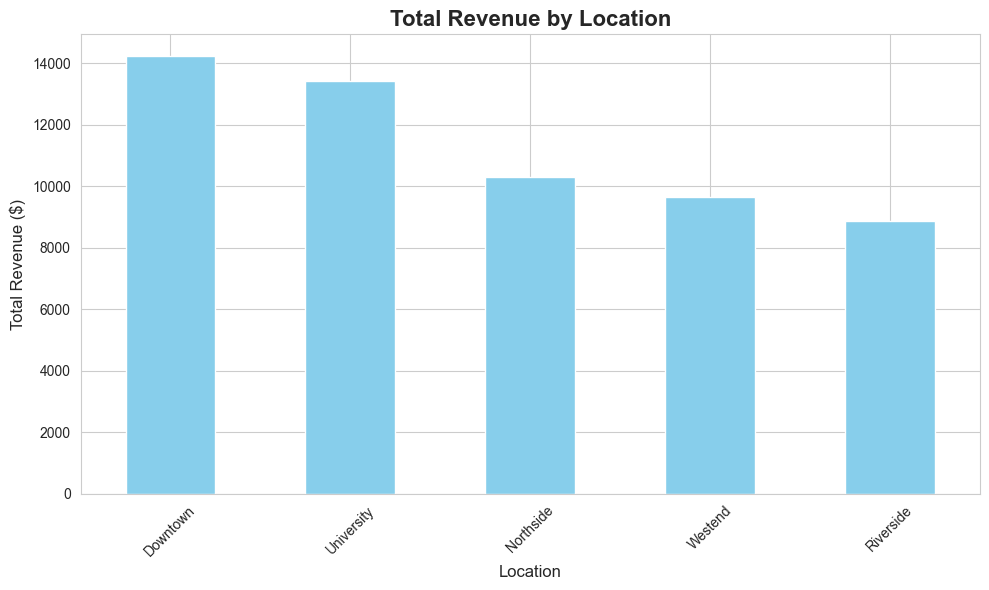

In [46]:
# TODO: Bar chart - revenue by location
plt.figure(figsize=(10, 6))
revenue_by_location.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Location', fontsize=16, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('revenue_by_location.png')
plt.show()

In [ ]:
# TODO: Bar chart - product popularity
plt.figure(figsize=(10, 6))
# Example: products_sold.plot(kind='bar', color='orange')
plt.title('Products Sold by Quantity', fontsize=16, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('products_sold.png')
plt.show()

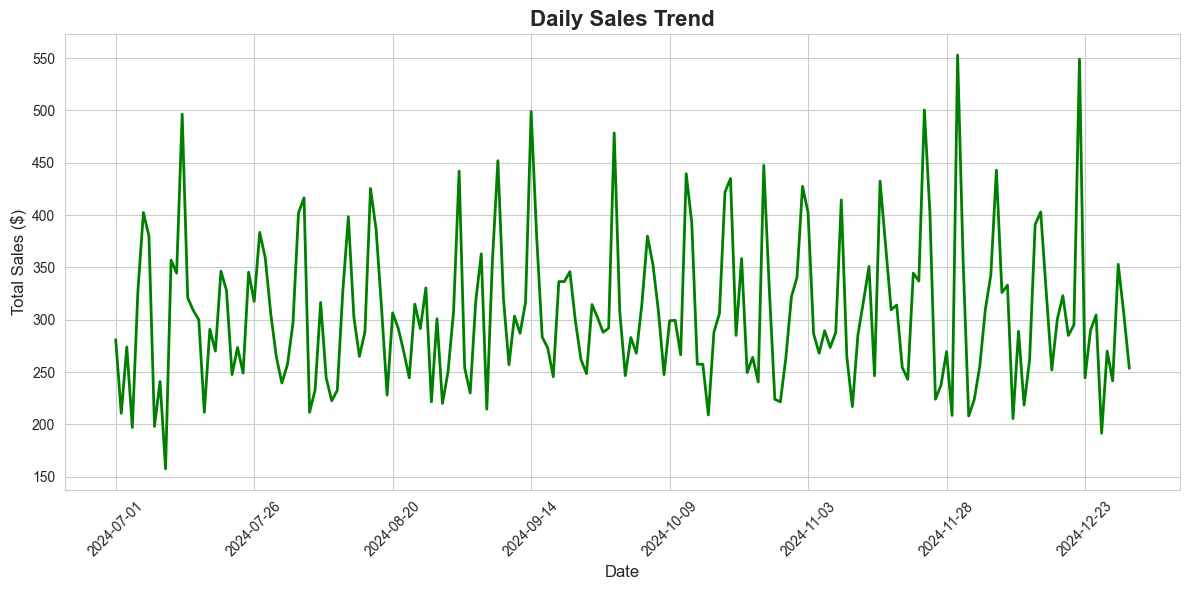

In [48]:
# TODO: Line plot - sales over time
# data['date'] = pd.to_datetime(data['date'])
# daily_sales = data.groupby('date')['total_sale'].sum()
daily_sales = data.groupby('date')['total_sale'].sum()  # replace with your series

plt.figure(figsize=(12, 6))
daily_sales.plot(kind='line', color='green', linewidth=2)
plt.title('Daily Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('sales_over_time.png')
plt.show()

## Part 5: Bonus Ideas (Optional)
- Sales by day of week
- Most popular product at each location
- Average transaction value

=== BONUS ANALYSIS ===

1. SALES BY DAY OF WEEK
   Monday: $7,644.50
   Tuesday: $7,009.00
   Wednesday: $7,040.00
   Thursday: $7,379.50
   Friday: $7,570.50
   Saturday: $9,989.50
   Sunday: $9,819.50


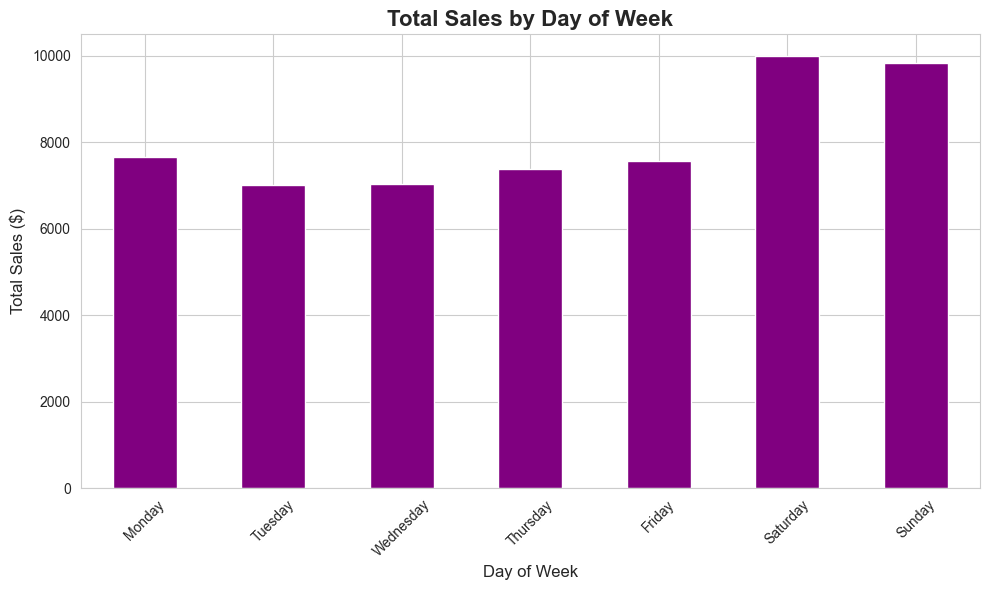


2. REVENUE BY LOCATION (DETAILED)
   Downtown: $14,222.00
   University: $13,422.50
   Northside: $10,293.50
   Westend: $9,650.50
   Riverside: $8,864.00


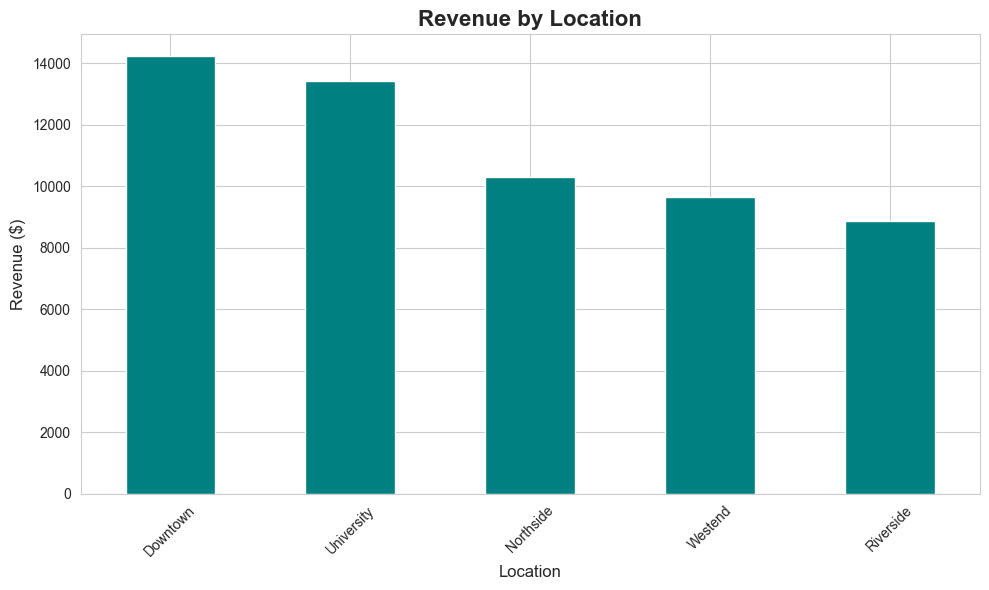


3. REVENUE BY PRODUCT
   Sandwich: $11,760.00
   Latte: $10,543.50
   Coffee: $9,492.00
   Pastry: $8,616.00
   Cappuccino: $8,064.00
   Espresso: $4,191.00
   Tea: $3,786.00


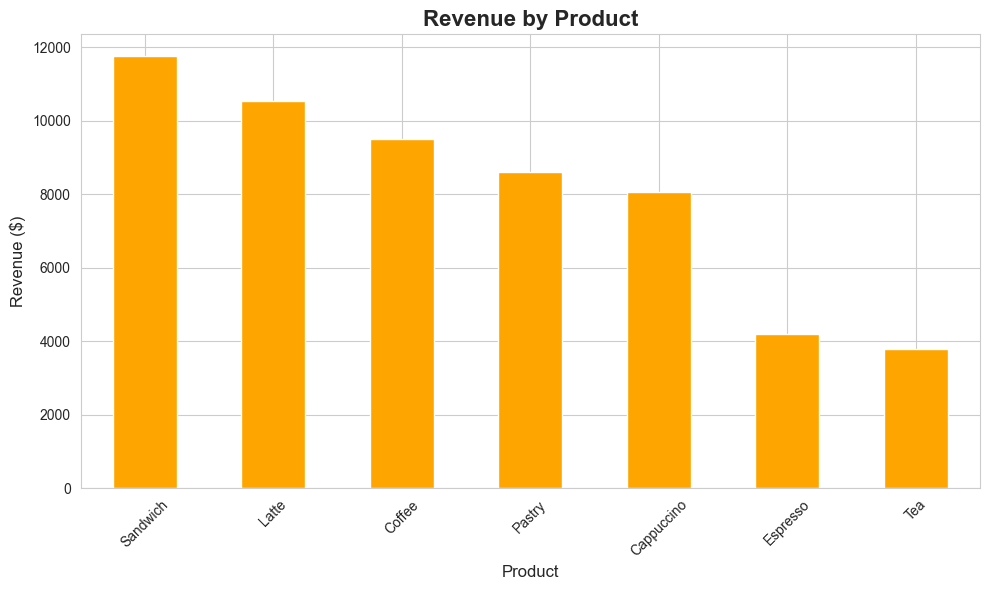


4. MOST POPULAR PRODUCT AT EACH LOCATION
   Downtown: Coffee (684 units)
   Northside: Coffee (465 units)
   Riverside: Coffee (446 units)
   University: Coffee (663 units)
   Westend: Latte (462 units)

5. AVERAGE TRANSACTION VALUE
   $6.02

=== FINAL SUMMARY STATISTICS ===

Highest revenue location: Downtown
  Revenue: $14,222.00

Top product: Coffee
  Units sold: 2,712

Sales trend highlights:
  Total revenue: $56,452.50
  Average daily sales: $306.81
  Peak daily sales: $553.00
  Lowest daily sales: $157.50



In [56]:
# Bonus Analysis 1: Sales by day of week
data['date'] = pd.to_datetime(data['date'])
data['day_of_week'] = data['date'].dt.day_name()
sales_by_day = data.groupby('day_of_week')['total_sale'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

print("=== BONUS ANALYSIS ===\n")
print("1. SALES BY DAY OF WEEK")
for day, sales in sales_by_day.items():
    print(f"   {day}: ${sales:,.2f}")

plt.figure(figsize=(10, 6))
sales_by_day.plot(kind='bar', color='purple')
plt.title('Total Sales by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bonus Analysis 2: Revenue by location (detailed)
print("\n2. REVENUE BY LOCATION (DETAILED)")
revenue_by_location_detailed = data.groupby('location')['total_sale'].sum().sort_values(ascending=False)
for location, revenue in revenue_by_location_detailed.items():
    print(f"   {location}: ${revenue:,.2f}")

plt.figure(figsize=(10, 6))
revenue_by_location_detailed.plot(kind='bar', color='teal')
plt.title('Revenue by Location', fontsize=16, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bonus Analysis 3: Revenue by product (all coffee types)
print("\n3. REVENUE BY PRODUCT")
revenue_by_product = data.groupby('product')['total_sale'].sum().sort_values(ascending=False)
for product, revenue in revenue_by_product.items():
    print(f"   {product}: ${revenue:,.2f}")

plt.figure(figsize=(10, 6))
revenue_by_product.plot(kind='bar', color='orange')
plt.title('Revenue by Product', fontsize=16, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bonus Analysis 4: Most popular product at each location
print("\n4. MOST POPULAR PRODUCT AT EACH LOCATION")
product_by_location = data.groupby(['location', 'product'])['quantity'].sum().reset_index()
most_popular = product_by_location.loc[product_by_location.groupby('location')['quantity'].idxmax()]
for _, row in most_popular.iterrows():
    print(f"   {row['location']}: {row['product']} ({row['quantity']} units)")

# Bonus Analysis 5: Average transaction value
avg_transaction = data['total_sale'].mean()
print(f"\n5. AVERAGE TRANSACTION VALUE")
print(f"   ${avg_transaction:.2f}")

# Bonus Analysis 6: Advanced Visualization - Stacked Bar Charts by Location
print("\n6. PRODUCT SALES BY DAY OF WEEK FOR EACH LOCATION")
print("   Creating 5 separate stacked bar charts...\n")

# Get all locations
locations = sorted(data['location'].unique())
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create a separate chart for each location
for location in locations:
    # Filter data for this location
    location_data = data[data['location'] == location]
    
    # Pivot to get products as columns and days as rows
    pivot_data = location_data.pivot_table(
        index='day_of_week',
        columns='product',
        values='total_sale',
        aggfunc='sum',
        fill_value=0
    ).reindex(day_order)
    
    # Create individual stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    
    # Styling
    ax.set_title(f'{location} - Product Sales by Day of Week', fontsize=16, fontweight='bold')
    ax.set_xlabel('Day of Week', fontsize=12)
    ax.set_ylabel('Sales ($)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Products', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary for this location
    total_location_sales = location_data['total_sale'].sum()
    best_day = pivot_data.sum(axis=1).idxmax()
    best_day_sales = pivot_data.sum(axis=1).max()
    
    print(f"   {location}:")
    print(f"     Total sales: ${total_location_sales:,.2f}")
    print(f"     Best day: {best_day} (${best_day_sales:,.2f})")
    print()

# Calculate summary statistics for Final Summary section
highest_revenue_location = revenue_by_location.index[0]
highest_revenue_amount = revenue_by_location.iloc[0]

top_product = products_sold.index[0]
top_product_quantity = products_sold.iloc[0]

total_revenue = data['total_sale'].sum()
avg_daily_sales = daily_sales.mean()
max_daily_sales = daily_sales.max()
min_daily_sales = daily_sales.min()

print("\n" + "="*50)
print("=== FINAL SUMMARY STATISTICS ===")
print("="*50)
print(f"\nHighest revenue location: {highest_revenue_location}")
print(f"  Revenue: ${highest_revenue_amount:,.2f}")
print(f"\nTop product: {top_product}")
print(f"  Units sold: {top_product_quantity:,}")
print(f"\nSales trend highlights:")
print(f"  Total revenue: ${total_revenue:,.2f}")
print(f"  Average daily sales: ${avg_daily_sales:,.2f}")
print(f"  Peak daily sales: ${max_daily_sales:,.2f}")
print(f"  Lowest daily sales: ${min_daily_sales:,.2f}")
print("\n" + "="*50)

# Data Dictionary:
# - location: Which coffee shop (Downtown, Northside, Westend, University, Riverside)
# - product: Item sold (Coffee, Espresso, Latte, Cappuccino, Tea, Pastry, Sandwich)
# - quantity: Number of items sold
# - price: Price per item ($)
# - total_sale: Total revenue (quantity × price)

## Final Summary (Completed)

### Key Findings:
- **Highest revenue location:** Downtown - $14,222.00
- **Top product:** Coffee - 2,712 units sold
- **Sales trend highlights:** 
  - Total revenue across all locations: $56,452.50
  - Average daily sales: $306.81
  - Sales range from $157.50 to $553.00 per day

### Recommendation for Jamie: 
Focus inventory and staffing resources on the **Downtown** location as it generates the highest revenue. Ensure adequate stock of **Coffee** since it's the top-selling product across all locations. Investigate factors contributing to peak sales days ($553) to replicate success more consistently. Consider day-of-week patterns from the bonus analysis to optimize staffing schedules.